In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load the dataset
file_path = '../../data/Data3.csv'  # Ensure the file is in the same directory
data = pd.read_csv(file_path)

# Create a 'Site' column with the first 7 letters of the 'ERBS' column
data['Site'] = data['ERBS'].str[:7]

# Group by 'Site' and 'STARTTIME_DATE', then average the values
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

# Normalize the 'DL_TRAFFIC_MB' column between 0 and 10
scaler = MinMaxScaler(feature_range=(0, 10))
grouped_data['DL_TRAFFIC_MB'] = scaler.fit_transform(grouped_data[['DL_TRAFFIC_MB']])

# Function to fit ARIMA model and predict
def fit_arima_model(train):
    model = ARIMA(train, order=(5, 1, 0))  # You can adjust the ARIMA parameters as needed
    fitted_model = model.fit()
    return fitted_model

# Function to create sequences for ARIMA (train-test split)
def create_train_test_split(data, seq_length):
    train_size = int(len(data) * 0.8)
    return data[:train_size], data[train_size:]

# Function for ARIMA prediction and plotting
def arima_prediction_and_plot(target_column):
    results = {}
    degradation_count = 0
    increase_count = 0
    site_predictions = {}

    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        train, test = create_train_test_split(site_data, seq_length)
        
        # Fit ARIMA model
        model = fit_arima_model(train)
        predictions = model.forecast(steps=len(test))
        
        # MSE Calculation
        test_mse = mean_squared_error(test, predictions)
        
        results[site] = test_mse
        site_predictions[site] = (test, predictions)
        
        # Degradation and increase check
        degradation = ((test - predictions) / test) >= 0.5
        increase = ((predictions - test) / test) >= 0.001
        degradation_count += np.sum(degradation)
        increase_count += np.sum(increase)
    
    return results, site_predictions, degradation_count, increase_count

# Plot actual vs predicted for ARIMA
def plot_actual_vs_predicted(site, y_true, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('DL_TRAFFIC_MB')
    plt.legend()
    plt.show()

# Run the prediction for 'DL_TRAFFIC_MB'
dl_traffic_mb_results, site_predictions, degradation_count, increase_count = arima_prediction_and_plot('DL_TRAFFIC_MB')

# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(dl_traffic_mb_results.items(), key=lambda x: x[1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

C:\Users\HP\AppData\Local\Temp\ipykernel_35832\129358956.py:16: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Skipping site BMBNC54 due to insufficient data.


C:\Users\HP\AppData\Local\Temp\ipykernel_35832\129358956.py:61: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\129358956.py:62: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\129358956.py:61: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\129358956.py:62: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001


Best 5 Sites based on MSE: [('BMBNC49', 0.005250292178364082), ('BMBNC48', 0.012857030806257788), ('BMBNC56', 0.01998491252336885), ('BMBNC50', 0.03791231607001761), ('CGANW20', 0.04411226862385533)]
Worst 5 Sites based on MSE: [('CXUKH32', 5.524558068321007), ('CXUKH04', 6.073201109090016), ('CXUKH21', 6.125851602971954), ('CXUKH02', 6.854886549091513), ('CXUKH16', 6.934496550995664)]


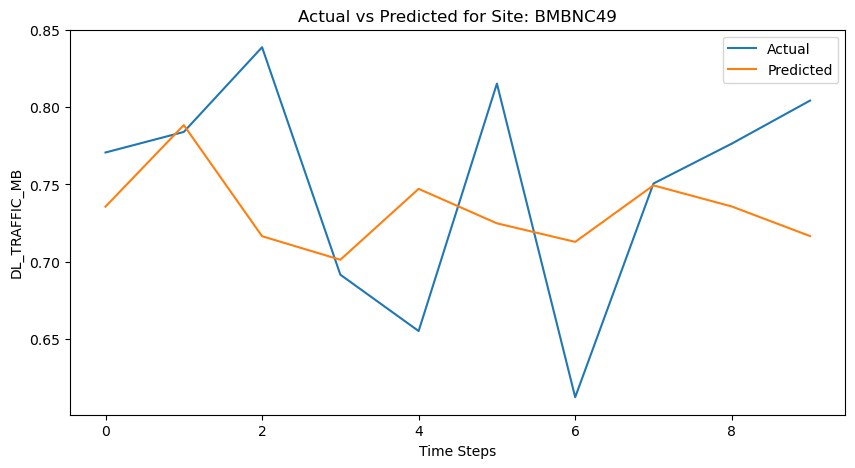

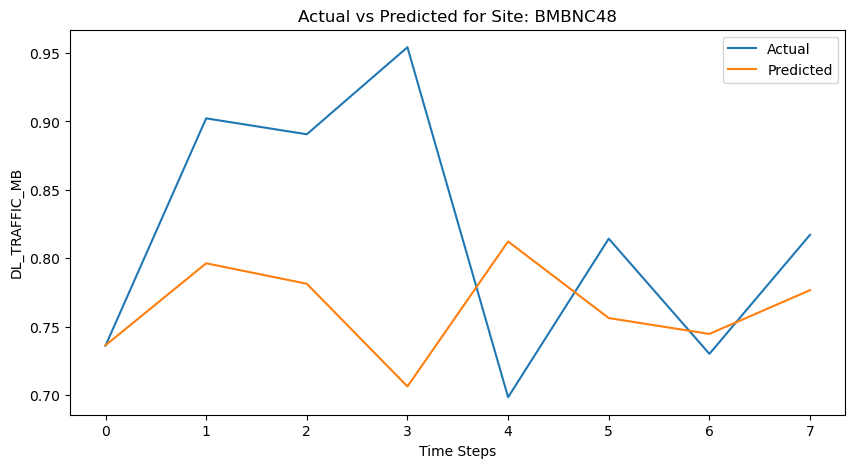

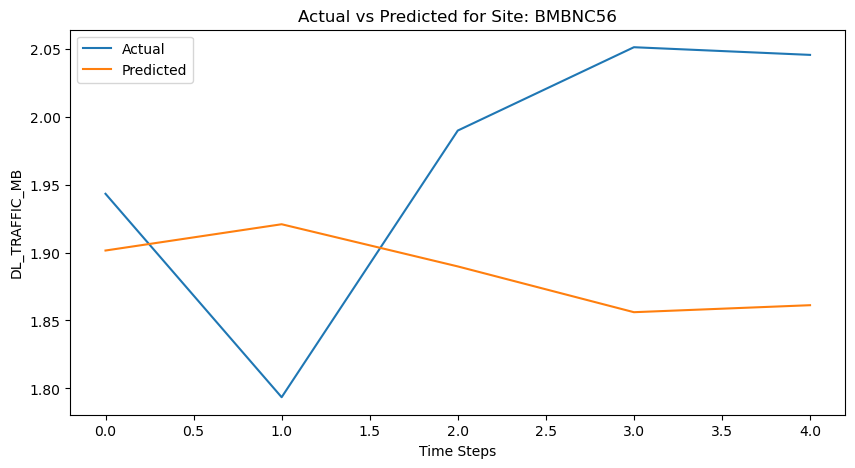

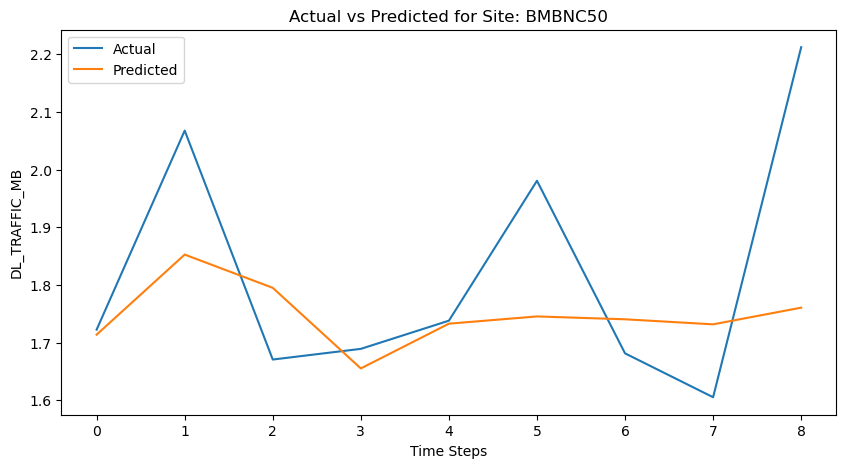

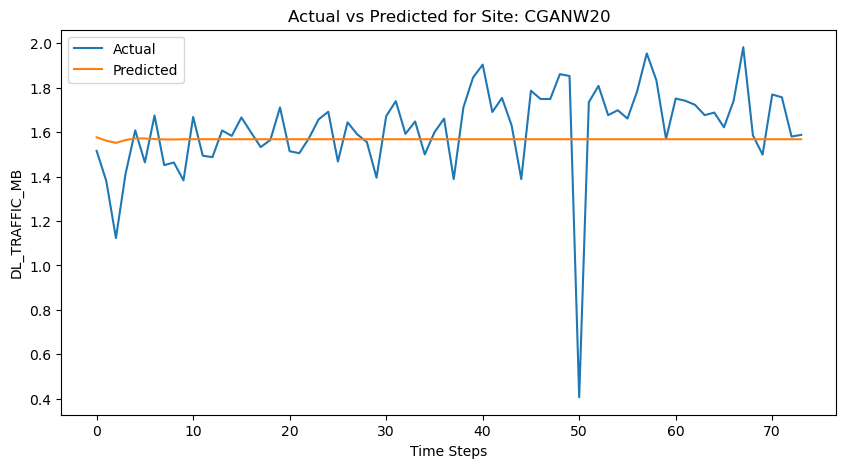

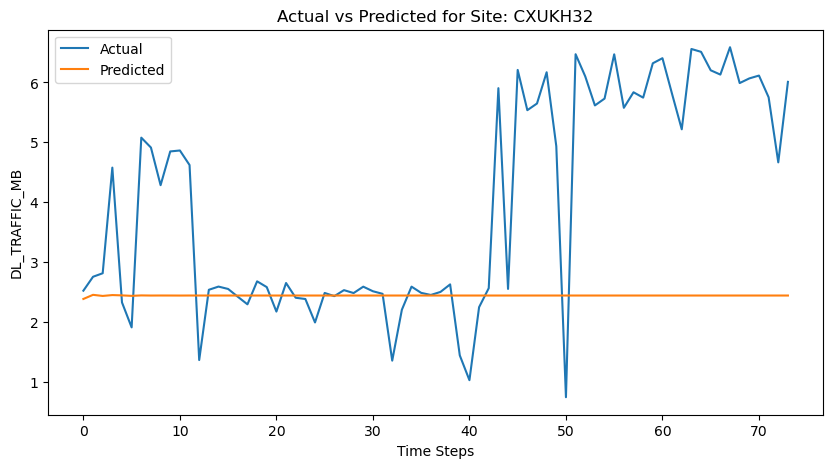

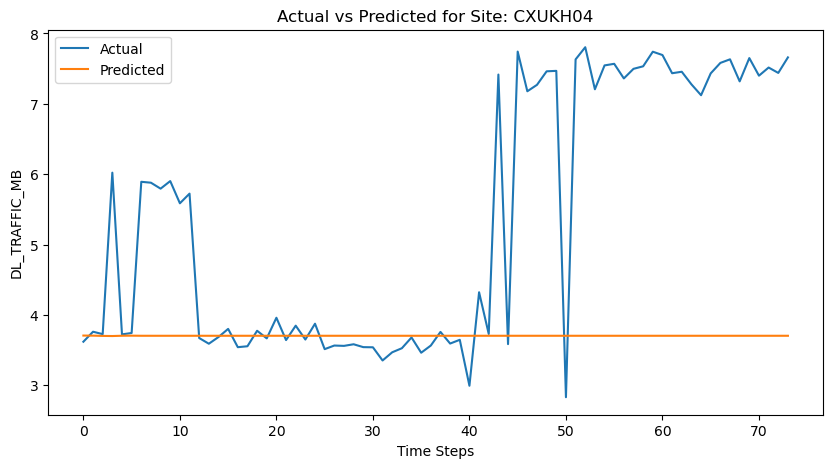

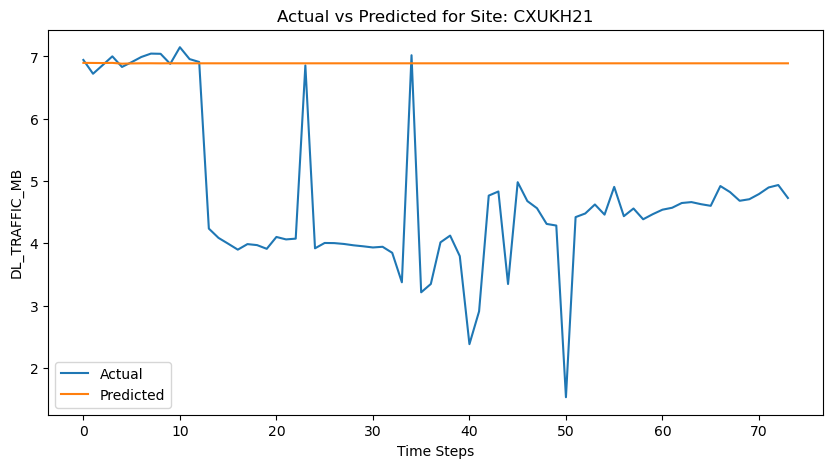

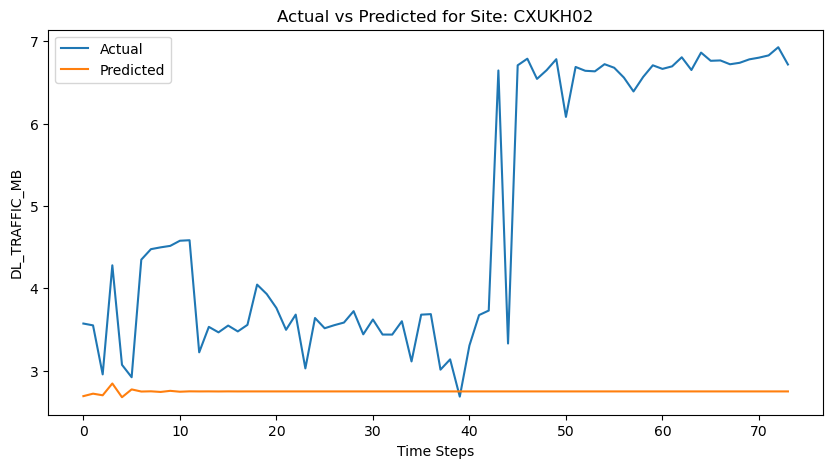

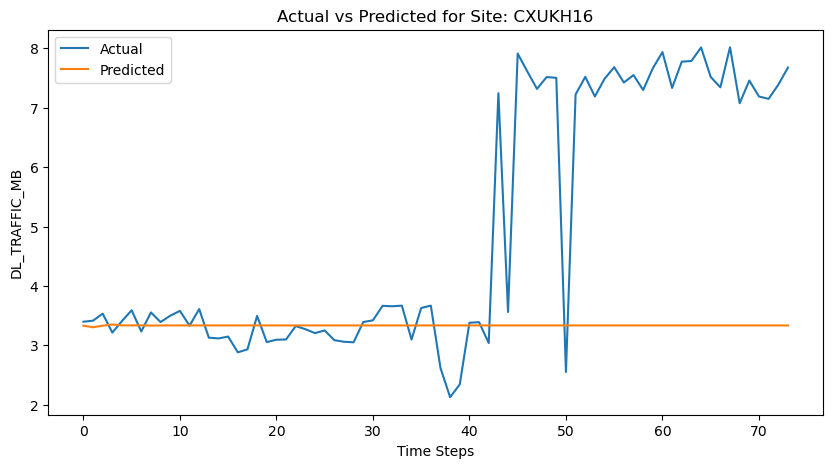

In [2]:
# Plot for the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    y_true, y_pred = site_predictions[site]
    plot_actual_vs_predicted(site, y_true, y_pred)

In [4]:
# Load the dataset
file_path = '../../data/Data3.csv'  # Ensure the file is in the same directory
data = pd.read_csv(file_path)

# Create a 'Site' column with the first 7 letters of the 'ERBS' column
data['Site'] = data['ERBS'].str[:7]

# Group by 'Site' and 'STARTTIME_DATE', then average the values
grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()

# Normalize the 'AVG_NO_USER' column between 0 and 10
scaler = MinMaxScaler(feature_range=(0, 10))
grouped_data['AVG_NO_USER'] = scaler.fit_transform(grouped_data[['AVG_NO_USER']])

# Function to fit ARIMA model and predict
def fit_arima_model(train):
    model = ARIMA(train, order=(5, 1, 0))  # You can adjust the ARIMA parameters as needed
    fitted_model = model.fit()
    return fitted_model

# Function to create sequences for ARIMA (train-test split)
def create_train_test_split(data, seq_length):
    train_size = int(len(data) * 0.8)
    return data[:train_size], data[train_size:]

# Function for ARIMA prediction and plotting
def arima_prediction_and_plot(target_column):
    results = {}
    degradation_count = 0
    increase_count = 0
    site_predictions = {}

    for site in grouped_data['Site'].unique():
        site_data = grouped_data[grouped_data['Site'] == site][target_column].values
        
        seq_length = 10
        if len(site_data) <= seq_length:
            print(f"Skipping site {site} due to insufficient data.")
            continue
        
        train, test = create_train_test_split(site_data, seq_length)
        
        # Fit ARIMA model
        model = fit_arima_model(train)
        predictions = model.forecast(steps=len(test))
        
        # MSE Calculation
        test_mse = mean_squared_error(test, predictions)
        
        results[site] = test_mse
        site_predictions[site] = (test, predictions)
        
        # Degradation and increase check
        degradation = ((test - predictions) / test) >= 0.5
        increase = ((predictions - test) / test) >= 0.001
        degradation_count += np.sum(degradation)
        increase_count += np.sum(increase)
    
    return results, site_predictions, degradation_count, increase_count

# Plot actual vs predicted for ARIMA
def plot_actual_vs_predicted(site, y_true, y_pred):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted for Site: {site}')
    plt.xlabel('Time Steps')
    plt.ylabel('AVG_NO_USER')
    plt.legend()
    plt.show()

# Run the prediction for 'AVG_NO_USER'
avg_no_user_results, site_predictions, degradation_count, increase_count = arima_prediction_and_plot('AVG_NO_USER')

# Get the best and worst 5 sites based on test MSE
sorted_results = sorted(avg_no_user_results.items(), key=lambda x: x[1])
best_5_sites = sorted_results[:5]
worst_5_sites = sorted_results[-5:]

print("Best 5 Sites based on MSE:", best_5_sites)
print("Worst 5 Sites based on MSE:", worst_5_sites)

C:\Users\HP\AppData\Local\Temp\ipykernel_35832\3997270262.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['Site', 'STARTTIME_DATE']).mean().reset_index()
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Skipping site BMBNC54 due to insufficient data.


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\3997270262.py:54: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\3997270262.py:55: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\3997270262.py:54: RuntimeWarning: divide by zero encountered in divide
  degradation = ((test - predictions) / test) >= 0.5
C:\Users\HP\AppData\Local\Temp\ipykernel_35832\3997270262.py:55: RuntimeWarning: divide by zero encountered in divide
  increase = ((predictions - test) / test) >= 0.001


Best 5 Sites based on MSE: [('BMBNC53', 0.00021507828231141549), ('BMBNC48', 0.00022050354081003983), ('BMBNC49', 0.00036732587733097143), ('BMBNC55', 0.000843900352965805), ('BMBNC56', 0.0025657327140680645)]
Worst 5 Sites based on MSE: [('CXUKH63', 1.9086613414547706), ('CXUKH39', 2.0404351182857416), ('CXUKH06', 2.7042824762554156), ('CXUKH04', 3.2087622420204673), ('CXUKH64', 3.817105161800141)]


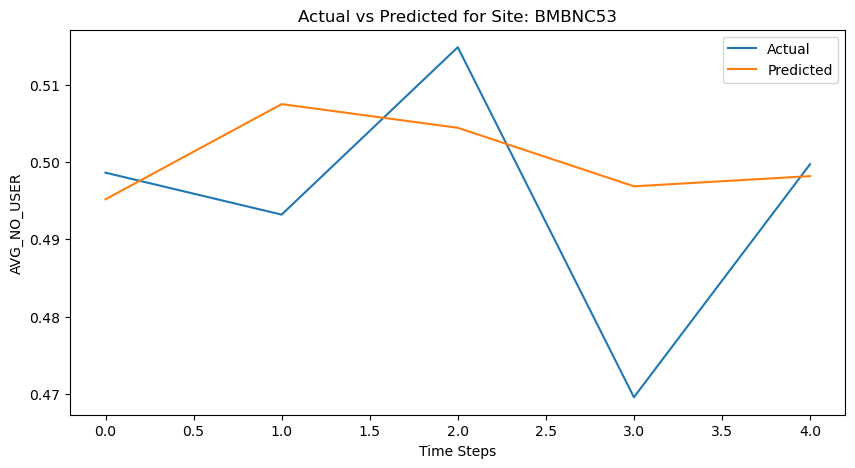

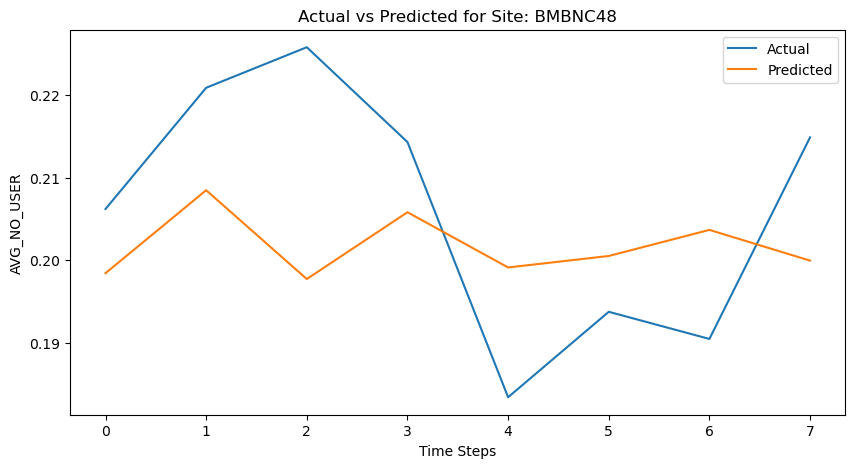

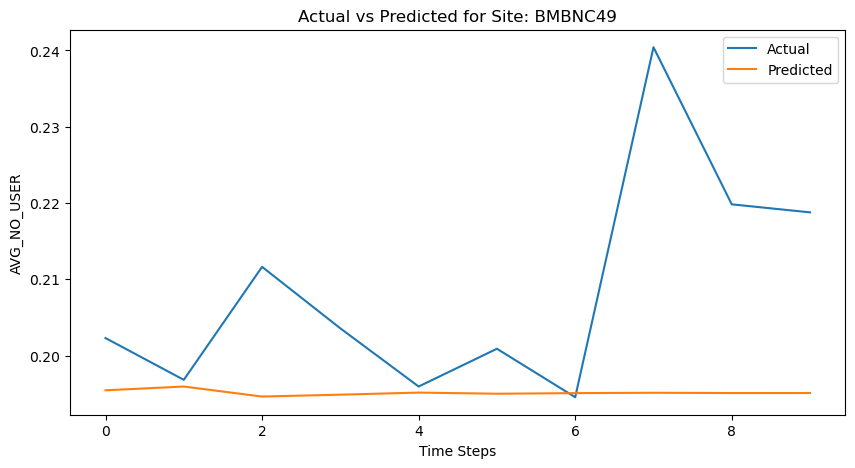

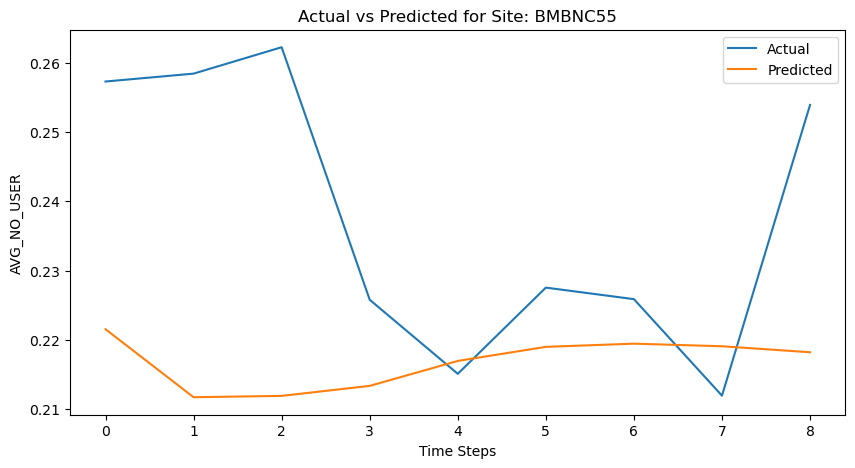

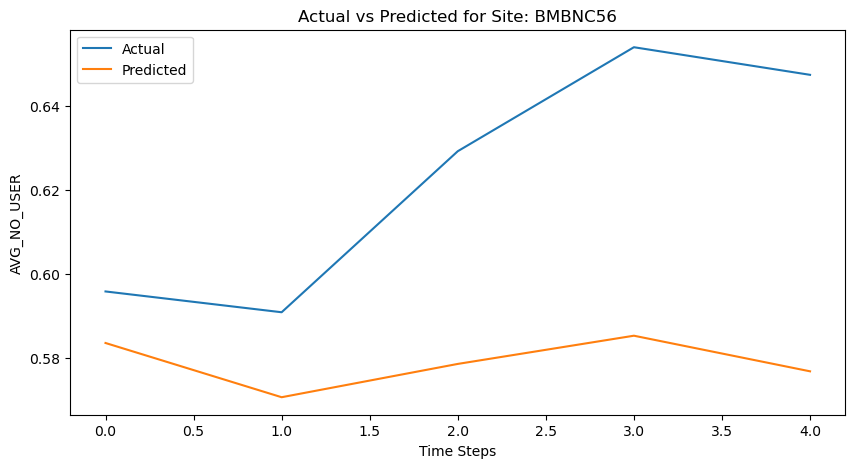

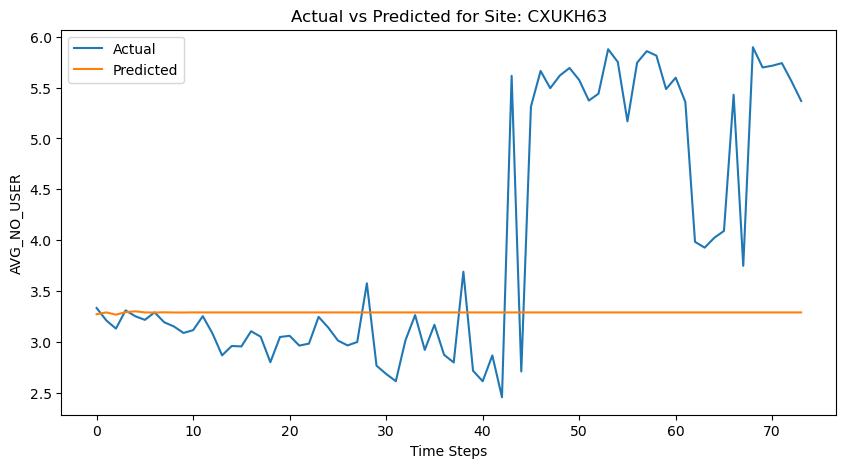

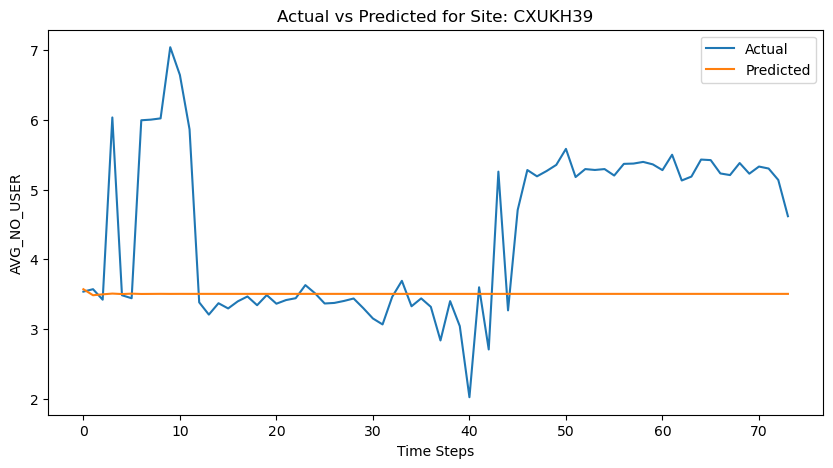

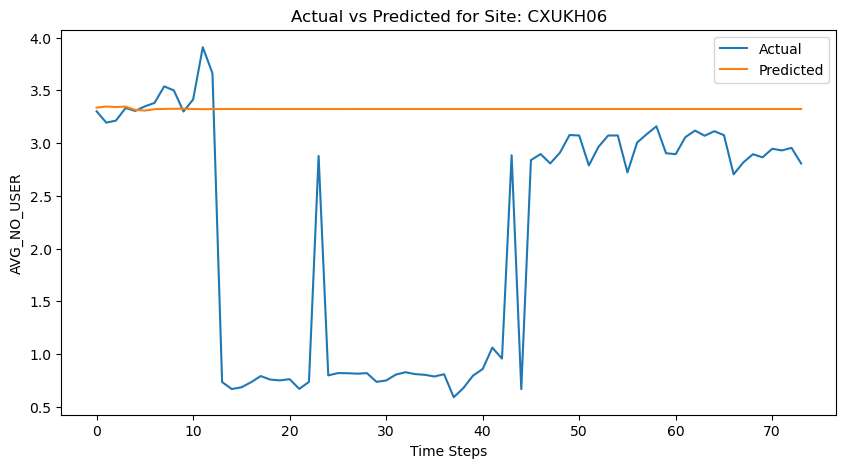

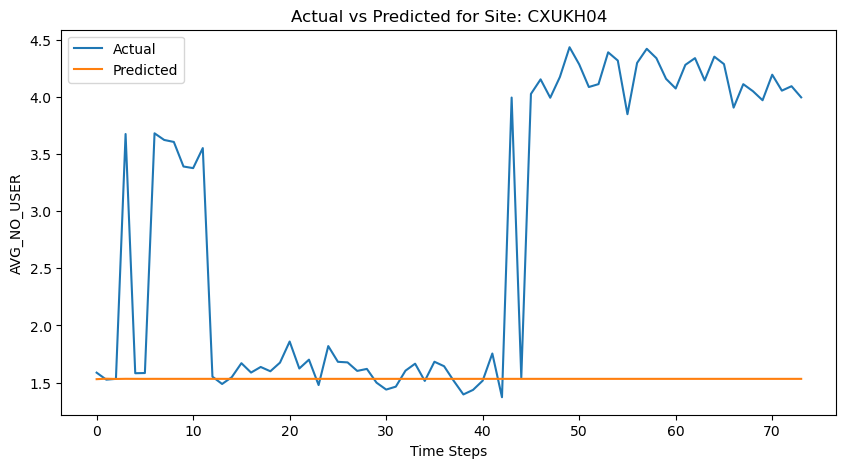

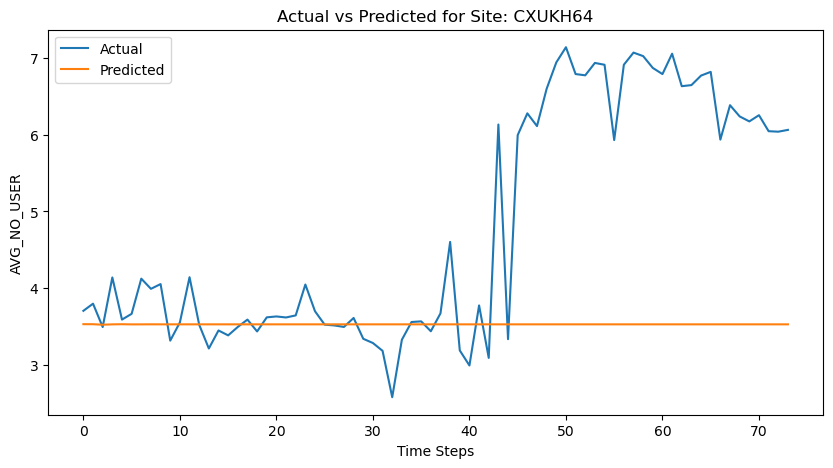

In [5]:
# Plot for the best and worst 5 sites
for site, _ in best_5_sites + worst_5_sites:
    y_true, y_pred = site_predictions[site]
    plot_actual_vs_predicted(site, y_true, y_pred)